# Load dataset

In [10]:
from src.load_data import load_images

In [11]:
if __name__ == "__main__":
    base_path = "data/Fotos"  
    dataset = load_images(base_path)

## Check dataset

In [3]:
for grupo, condiciones in dataset.items():
        for cond, imgs in condiciones.items():
            if imgs:
                shape = imgs[0]['image'].shape
                print(f"{grupo} - {cond}: {len(imgs)} imágenes | Dimensiones: {shape}")
            else:
                print(f"{grupo} - {cond}: 0 imágenes")

N3 y N4 - CTRL: 8 imágenes | Dimensiones: (1536, 2040, 3)
N3 y N4 - HPMC: 8 imágenes | Dimensiones: (1536, 2040, 3)
N1 y N2 - CTRL: 8 imágenes | Dimensiones: (1536, 2040, 3)
N1 y N2 - HPMC: 8 imágenes | Dimensiones: (1536, 2040, 3)


# Preprocesamiento: extraer canal verde y crear su dataset

In [4]:
from src.preprocessing import extract_green_channel

In [5]:
green_dataset = extract_green_channel(dataset)

## Normalizar todas las imágenes del dataset del canal verde

In [6]:
from src.preprocessing import normalize_dataset

In [7]:
green_norm_dataset = normalize_dataset(green_dataset, robust=True)

In [8]:
first_group = list(dataset.keys())[0]
first_cond = list(dataset[first_group].keys())[0]

print("dataset:", dataset[first_group][first_cond][0].keys())
print("green_dataset:", green_dataset[first_group][first_cond][0].keys())
print("green_norm_dataset:", green_norm_dataset[first_group][first_cond][0].keys())

dataset: dict_keys(['name', 'image', 'true_group'])
green_dataset: dict_keys(['name', 'image', 'true_group'])
green_norm_dataset: dict_keys(['name', 'image', 'true_group'])


# Extraemos features

In [9]:
from pipeline import  build_feature_dataset

df_features = build_feature_dataset(
    green_norm_dataset,
    q=80,
    variant="closing_r3",
    prune_iters=5
)

print(df_features.head())
print(df_features.shape)

df_features.to_csv("features_dataset.csv", index=False)

   mask_area  fill_ratio  n_components  largest_component_area  \
0     625941    0.199762           204                163099.0   
1     624311    0.199241           175                190454.0   
2     621550    0.198360           213                 89631.0   
3     613061    0.195651           185                134901.0   
4     619155    0.197596           185                131895.0   

   largest_component_ratio  mean_component_area  std_component_area  \
0                 0.260566          3068.338235        12402.225358   
1                 0.305063          3567.491429        16897.021487   
2                 0.144206          2918.075117         8947.731597   
3                 0.220045          3313.843243        12953.616990   
4                 0.213024          3346.783784        11455.238153   

   median_component_area  skeleton_length  n_endpoints  ...  \
0                  582.5            35102         1066  ...   
1                  636.0            35829         

condition                         CTRL           HPMC
mask_area                620038.375000  618926.000000
fill_ratio                    0.197878       0.197523
n_components                199.312500     174.687500
largest_component_area   132427.187500  303127.812500
largest_component_ratio       0.213300       0.488884
mean_component_area        3142.325144    3639.938444
std_component_area        11961.233177   24840.595586
median_component_area       582.843750     459.875000
skeleton_length           36254.562500   49618.312500
n_endpoints                1006.000000    1033.500000
n_junctions                2900.500000    3593.062500
endpoint_density              0.000321       0.000330
junction_density              0.000926       0.001147
branch_density                0.011570       0.015835
n_segments                 1769.375000    2079.812500
mean_segment_length          18.764848      22.105045
median_segment_length        13.687500      15.812500
max_segment_length          

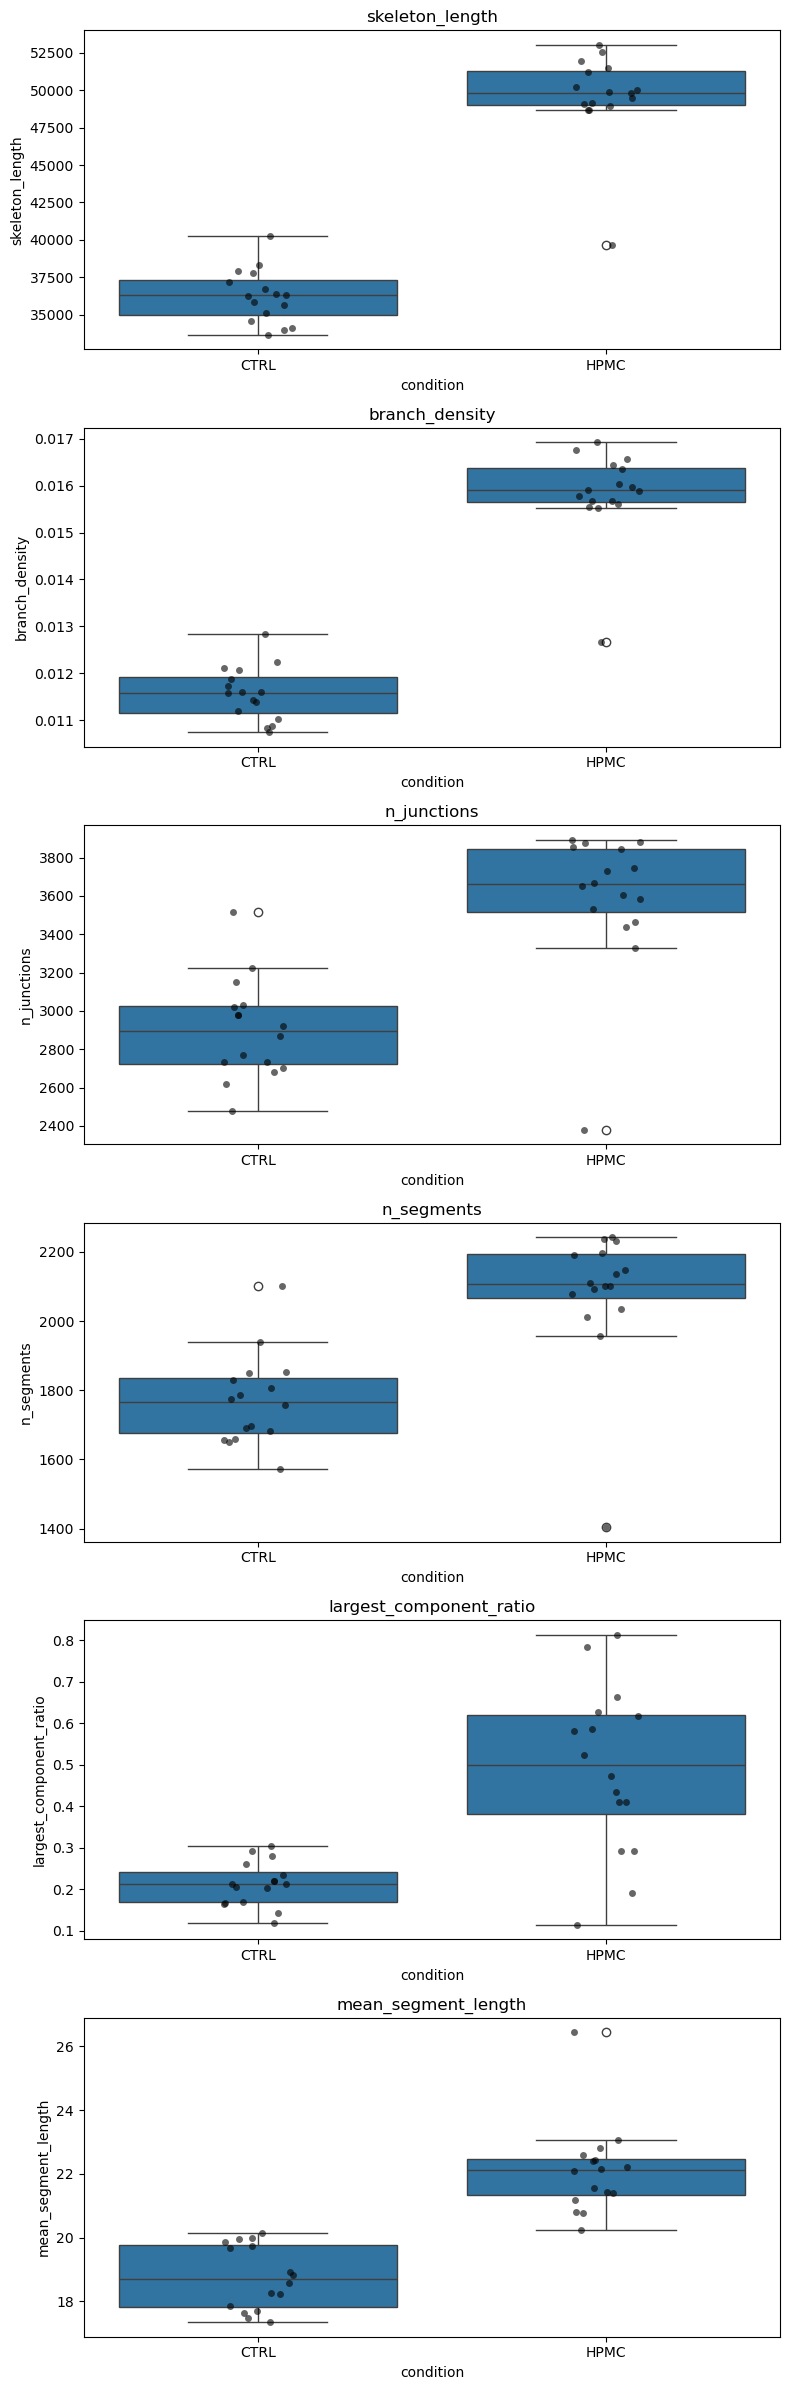

In [10]:
import pandas as pd

df_features = pd.read_csv("features_dataset.csv")

summary = df_features.groupby("condition").mean(numeric_only=True)
print(summary.T)

# VISUALIZAMOS FEATURES
from pipeline import plot_feature_boxplots

plot_feature_boxplots(df_features, [
    "skeleton_length",
    "branch_density",
    "n_junctions",
    "n_segments",
    "largest_component_ratio",
    "mean_segment_length"
])

In [11]:
import pandas as pd
from src.features import rank_features, print_report

df_features = pd.read_csv("features_dataset.csv")

results = rank_features(df_features)
print_report(results, top_n=15)

results.to_csv("feature_ranking_results.csv", index=False)

  FEATURE IMPORTANCE REPORT  (top 15)
 rank                 feature importance_tier  composite_score_norm effect_size  sig_ttest  sig_mwu
    1        median_thickness          🔴 HIGH             99.421160       large       True     True
    2         skeleton_length          🔴 HIGH             99.164790       large       True     True
    3          branch_density          🔴 HIGH             99.164790       large       True     True
    4          mean_thickness          🔴 HIGH             88.238856       large       True     True
    5       median_tortuosity          🔴 HIGH             74.521151       large       True     True
    6   median_segment_length          🔴 HIGH             67.103681       large       True     True
    7     mean_segment_length          🔴 HIGH             63.632118       large       True     True
    8      std_segment_length          🔴 HIGH             58.562606       large       True     True
    9   median_component_area          🔴 HIGH             57.0

Reducir el dataset a un conjunto de features que sea:
- informativo
- poco redundante
- estable
- útil para clasificar CTRL vs HPMC

In [2]:
import pandas as pd

df_features = pd.read_csv("features_dataset.csv")
results_df = pd.read_csv("feature_ranking_results.csv")

In [3]:
from feature_selection_pipeline import get_strong_candidates

strong = get_strong_candidates(results_df)
print(strong)

[Step 1] Strong candidates from Stage 1: 21 features
         ['median_thickness', 'skeleton_length', 'branch_density', 'mean_thickness', 'median_tortuosity', 'median_segment_length', 'mean_segment_length', 'std_segment_length', 'median_component_area', 'junction_density', 'n_junctions', 'std_thickness', 'mean_tortuosity', 'n_segments', 'largest_component_ratio', 'std_component_area', 'largest_component_area', 'max_segment_length', 'max_thickness', 'n_components', 'mean_component_area']

['median_thickness', 'skeleton_length', 'branch_density', 'mean_thickness', 'median_tortuosity', 'median_segment_length', 'mean_segment_length', 'std_segment_length', 'median_component_area', 'junction_density', 'n_junctions', 'std_thickness', 'mean_tortuosity', 'n_segments', 'largest_component_ratio', 'std_component_area', 'largest_component_area', 'max_segment_length', 'max_thickness', 'n_components', 'mean_component_area']


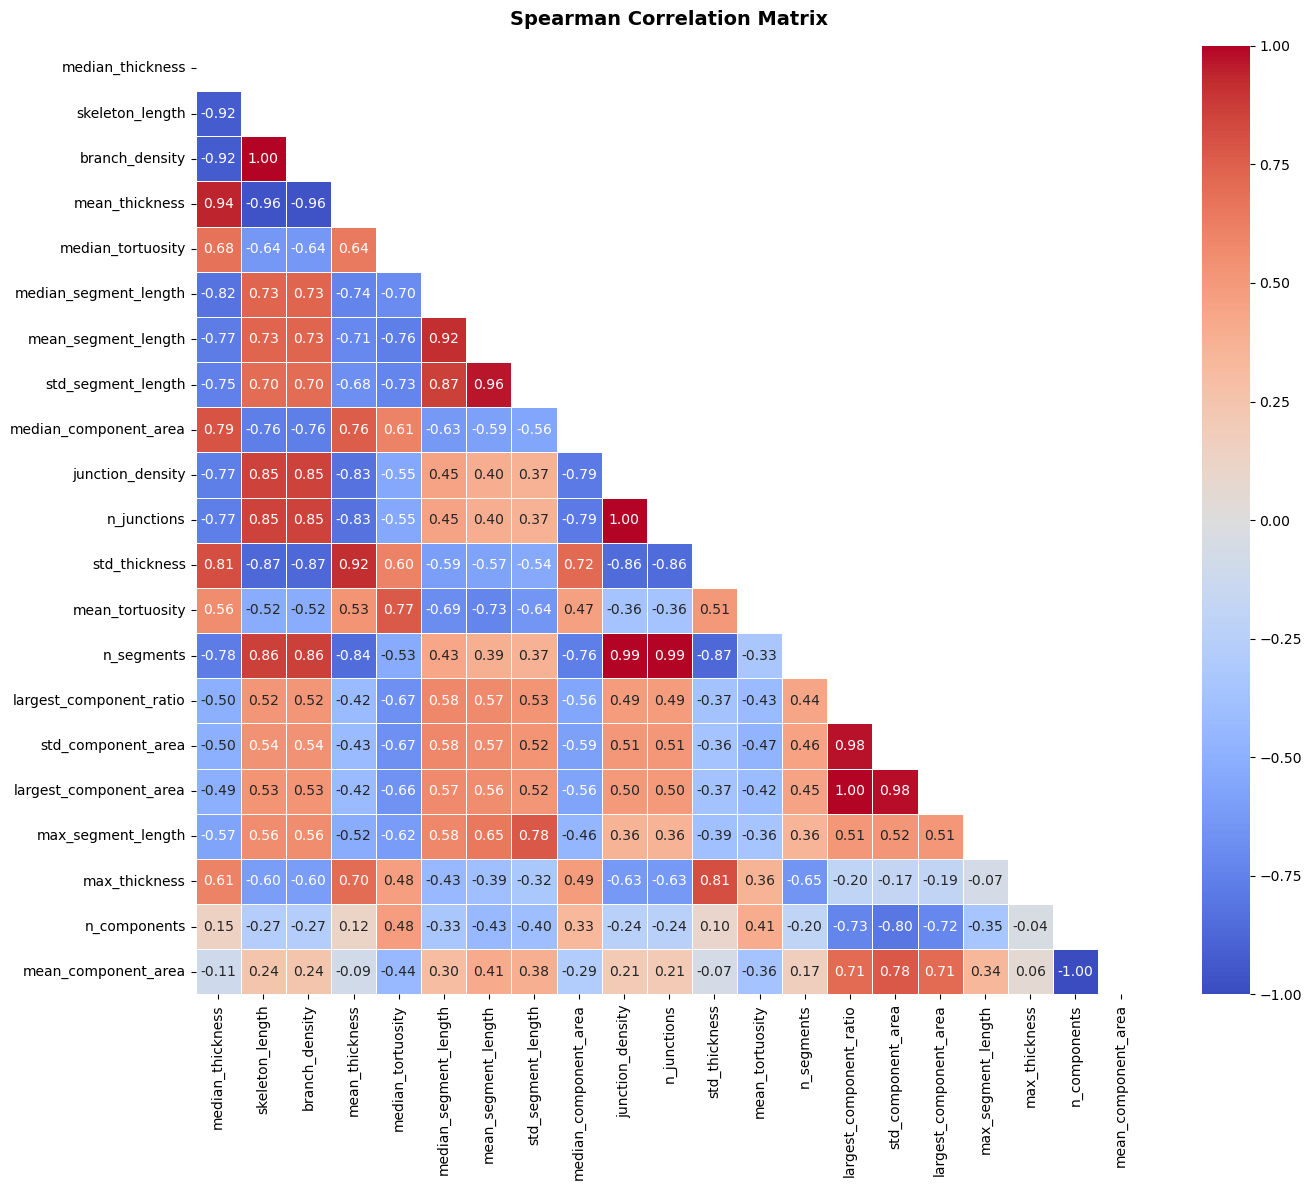

[Step 2] Correlation matrix saved → correlation_matrix.png

[Step 2] Pairs with |r| > 0.85:
              feature_a              feature_b  spearman_r  score_a  score_b                    kept                dropped
        skeleton_length         branch_density      1.0000    99.16    99.16         skeleton_length         branch_density
       junction_density            n_junctions      1.0000    49.89    49.89        junction_density            n_junctions
largest_component_ratio largest_component_area      0.9974    41.29    40.83 largest_component_ratio largest_component_area
           n_components    mean_component_area     -0.9954    19.65    18.53            n_components    mean_component_area
            n_junctions             n_segments      0.9926    49.89    44.17             n_junctions             n_segments
       junction_density             n_segments      0.9926    49.89    44.17        junction_density             n_segments
     std_component_area largest_componen

In [4]:
from feature_selection_pipeline import prune_correlated_features

pruned, corr_pairs = prune_correlated_features(df_features, strong, results_df)
print(pruned)
print(corr_pairs)

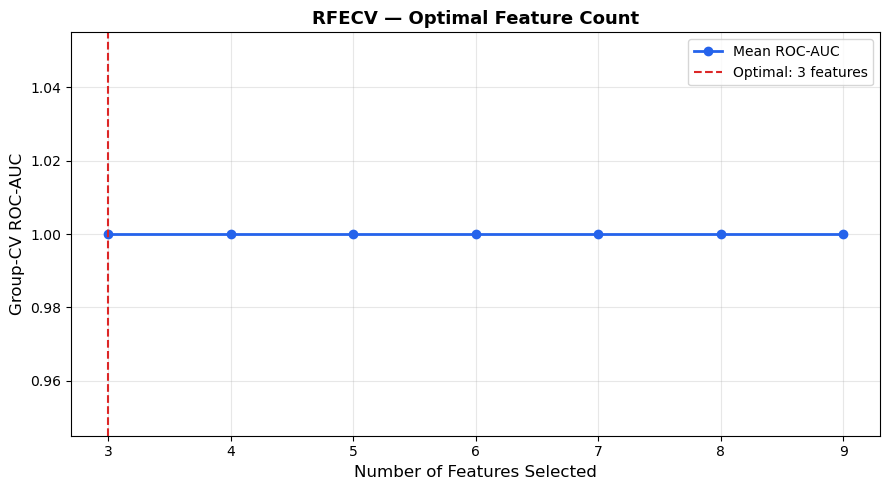

[Step 3] RFECV optimal features (3): ['median_thickness', 'median_tortuosity', 'median_segment_length']

['median_thickness', 'median_tortuosity', 'median_segment_length']


In [5]:
import importlib
import feature_selection_pipeline

importlib.reload(feature_selection_pipeline)

optimal, rfecv_obj = feature_selection_pipeline.run_rfecv(df_features, pruned)
print(optimal)

# Compare models

In [6]:
feature_sets = {
    f"All {len(results_df)} ranked features": [f for f in results_df["feature"].tolist() if f in df_features.columns],
    f"{len(strong)} HIGH-tier features": strong,
    f"{len(pruned)} after corr-pruning": pruned,
    f"{len(optimal)} RFECV optimal": optimal,
}

comparison = feature_selection_pipeline.compare_models(df_features, feature_sets)
print(comparison)

[Step 4] Model comparison results:
           Feature Set         Model  n_features       ROC-AUC            F1      Accuracy
All 28 ranked features   LogReg (L2)          28 1.000 ± 0.000 0.964 ± 0.062 0.969 ± 0.054
All 28 ranked features Random Forest          28 1.000 ± 0.000 0.964 ± 0.062 0.969 ± 0.054
 21 HIGH-tier features   LogReg (L2)          21 1.000 ± 0.000 1.000 ± 0.000 1.000 ± 0.000
 21 HIGH-tier features Random Forest          21 1.000 ± 0.000 0.964 ± 0.062 0.969 ± 0.054
  9 after corr-pruning   LogReg (L2)           9 1.000 ± 0.000 1.000 ± 0.000 1.000 ± 0.000
  9 after corr-pruning Random Forest           9 1.000 ± 0.000 1.000 ± 0.000 1.000 ± 0.000
       3 RFECV optimal   LogReg (L2)           3 1.000 ± 0.000 1.000 ± 0.000 1.000 ± 0.000
       3 RFECV optimal Random Forest           3 1.000 ± 0.000 1.000 ± 0.000 1.000 ± 0.000

              Feature Set          Model  n_features        ROC-AUC  \
0  All 28 ranked features    LogReg (L2)          28  1.000 ± 0.000   
1  

Las features finales serían:
- median_thickness
- median_tortuosity
- median_segment_length

Modelo elegido: Logistic Regression

## Análisis exploratorio/interpretativo del modelo final

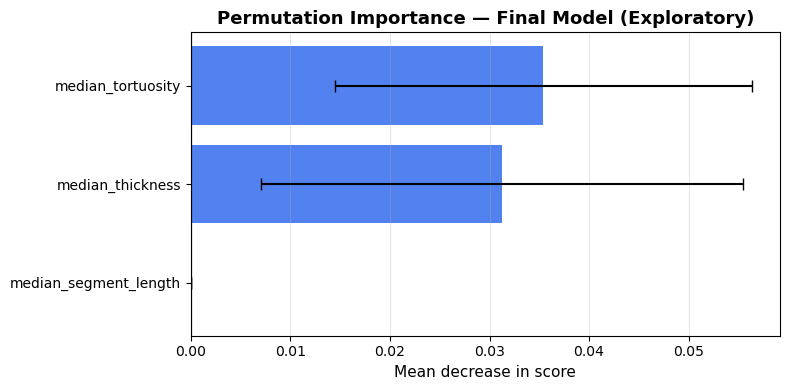

[Step 5] Permutation importance saved → permutation_importance.png


In [9]:
importlib.reload(feature_selection_pipeline)
feature_selection_pipeline.evaluate_final_model(df_features, optimal)

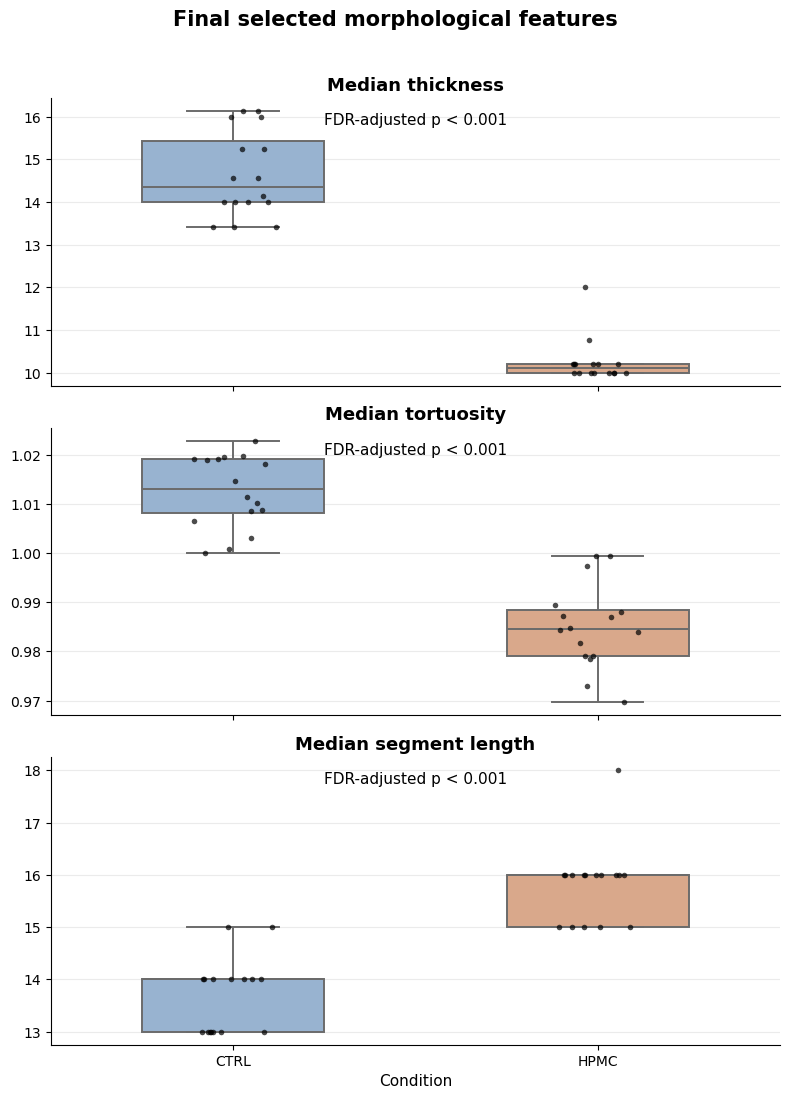

Saved → final_3_feature_boxplots.png


In [12]:
import importlib
import pipeline
importlib.reload(pipeline)

pipeline.plot_final_feature_boxplots(df_features)

# Save Model

In [7]:
import importlib
import final_binary_model
import pandas as pd

importlib.reload(final_binary_model)

df_features = pd.read_csv("features_dataset.csv")

model, metadata = final_binary_model.save_final_binary_model(df_features)

Modelo guardado en: final_binary_model.joblib
Metadata guardada en: final_binary_model_metadata.joblib


/Users/alexiagarciaguevara/miniconda3/envs/proyecto_astrocitos/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [8]:
loaded_model, loaded_metadata = final_binary_model.load_final_binary_model()
print(loaded_metadata)

{'features': ['median_thickness', 'median_tortuosity', 'median_segment_length'], 'target_mapping': {0: 'CTRL', 1: 'HPMC'}, 'model_type': 'LogisticRegression + StandardScaler', 'task': 'CTRL vs 72hs_LPS', 'q': 80, 'variant': 'closing_r3', 'prune_iters': 5}


## Try with a known image

### CTRL

In [14]:
new_img = dataset["N1 y N2"]["CTRL"][0]["image"]

In [16]:
result = final_binary_model.predict_inflammatory_state(new_img)

print("Predicción:", result["pred_label"])
print("Prob CTRL:", result["prob_CTRL"])
print("Prob HPMC:", result["prob_72hs_LPS"])
print("Features del modelo:", result["model_features"])

Predicción: CTRL
Prob CTRL: 0.988886505836211
Prob HPMC: 0.011113494163789041
Features del modelo: {'median_thickness': 16.1245154965971, 'median_tortuosity': 1.0101485816078168, 'median_segment_length': 13.0}


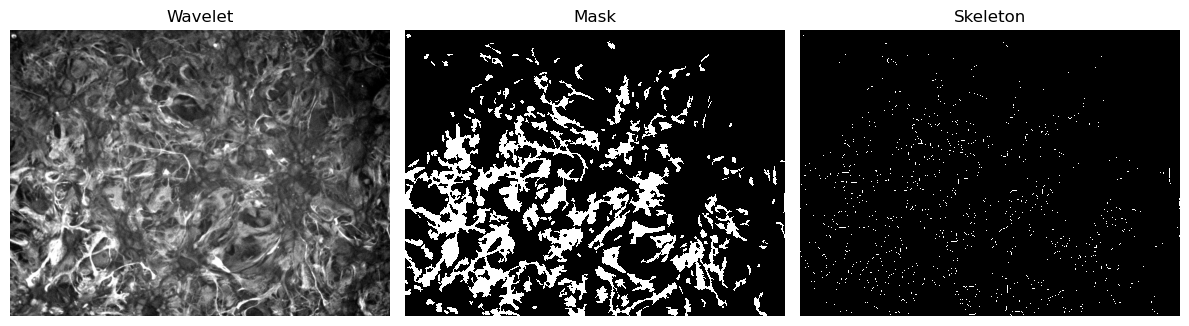

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(result["wavelet"], cmap="gray")
axes[0].set_title("Wavelet")

axes[1].imshow(result["mask"], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("Mask")

axes[2].imshow(result["skeleton"], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[2].set_title("Skeleton")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 72hs LPS (HPMC)

In [18]:
new_img = dataset["N1 y N2"]["HPMC"][0]["image"]

In [19]:
result = final_binary_model.predict_inflammatory_state(new_img)

print("Predicción:", result["pred_label"])
print("Prob CTRL:", result["prob_CTRL"])
print("Prob HPMC:", result["prob_72hs_LPS"])
print("Features del modelo:", result["model_features"])

Predicción: HPMC
Prob CTRL: 0.03836641990419265
Prob HPMC: 0.9616335800958073
Features del modelo: {'median_thickness': 10.0, 'median_tortuosity': 0.9879973829081764, 'median_segment_length': 16.0}


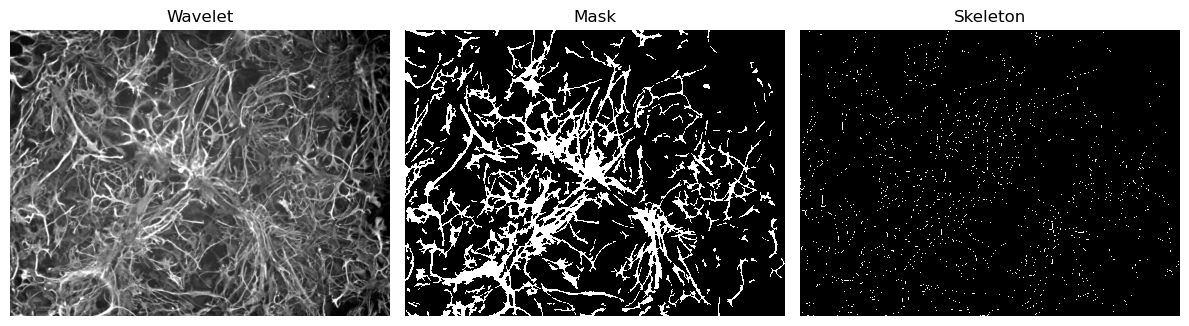

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(result["wavelet"], cmap="gray")
axes[0].set_title("Wavelet")

axes[1].imshow(result["mask"], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("Mask")

axes[2].imshow(result["skeleton"], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[2].set_title("Skeleton")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()